<a href="https://colab.research.google.com/github/lodigasatish-ai/teleconnect-ml-assignment/blob/main/notebooks/05_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Upload your dataset (CSV file)


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
File loaded successfully: WA_Fn-UseC_-Telco-Customer-Churn.csv

 Preprocessing data : 
Preprocessing completed!

 Training Random Forest model : 
Model training completed!

 SHAP Global Feature Importance : 


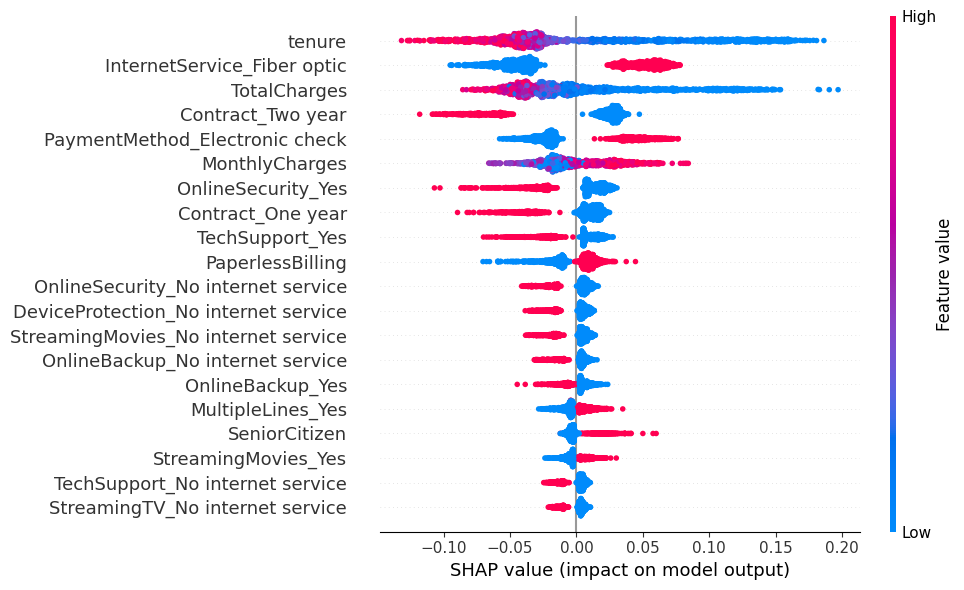


Top 5 Features Driving Customer Churn:
                           Feature  Importance
3                           tenure    0.060717
11     InternetService_Fiber optic    0.049222
7                     TotalCharges    0.039681
26               Contract_Two year    0.037819
28  PaymentMethod_Electronic check    0.031670

 Local Explanations : 

Explanation for a Churned Customer:


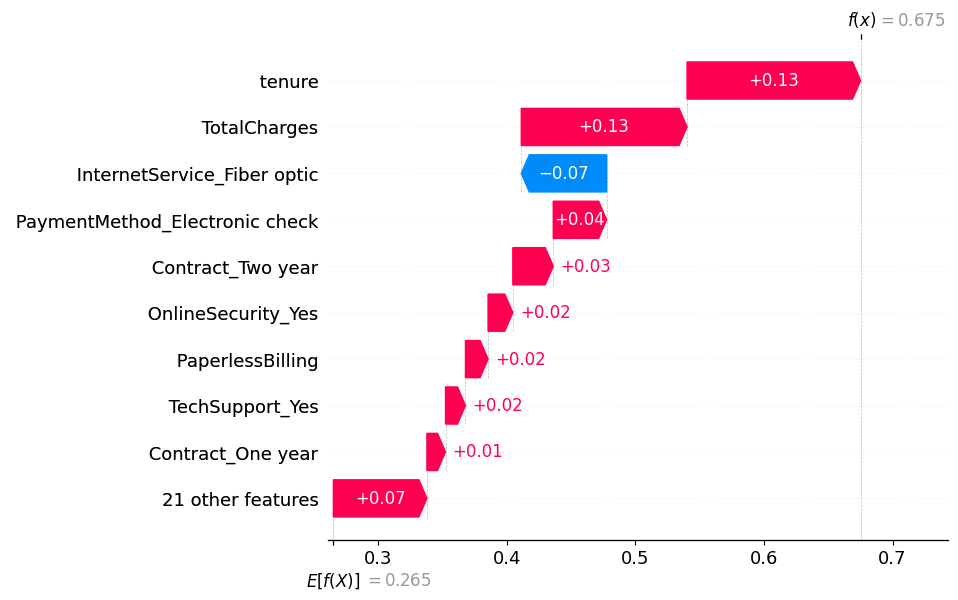


Explanation for a Retained Customer:


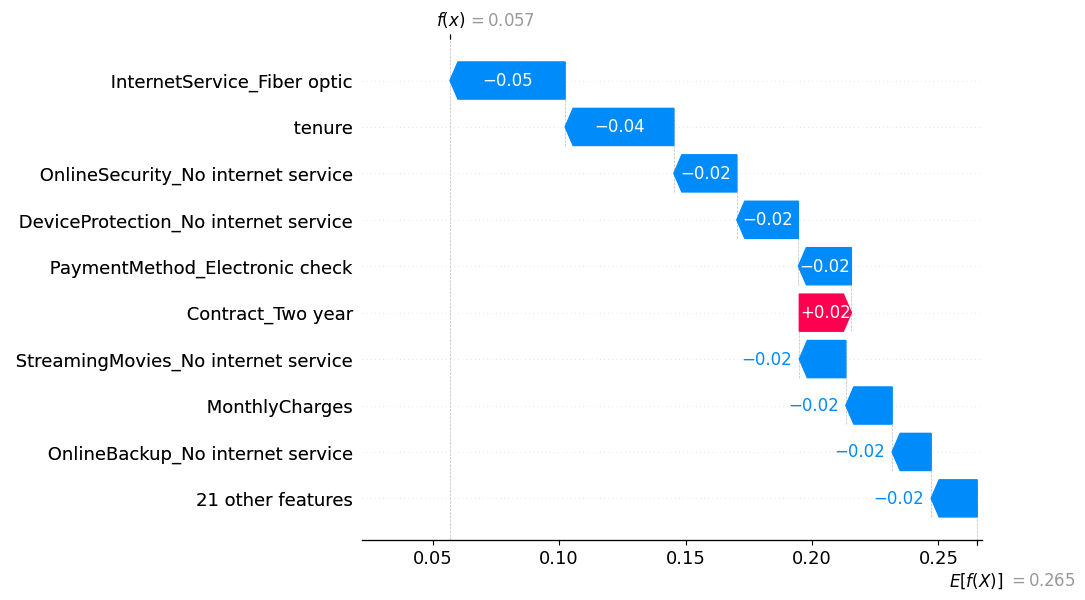

In [ ]:
# TASK 5: MODEL INTERPRETATION & BUSINESS RECOMMENDATIONS

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from google.colab import files

# UPLOAD DATASET
print(" Upload your dataset (CSV file)")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("File loaded successfully:", file_name)

# DATA PREPROCESSING
print("\n Preprocessing data : ")

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

for col in df.columns:
    if df[col].dtype == 'object':
        values = set(df[col].dropna().unique())
        if values <= {'Yes', 'No'}:
            df[col] = df[col].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, drop_first=True)
target_col = [col for col in df.columns if 'churn' in col.lower()][0]
X = df.drop(target_col, axis=1)
y = df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Preprocessing completed!")

# MODEL TRAINING
print("\n Training Random Forest model : ")
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
print("Model training completed!")

# SHAP GLOBAL FEATURE IMPORTANCE
print("\n SHAP Global Feature Importance : ")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    shap_array = shap_values

# Fix for newer SHAP versions (3D → 2D)
if len(shap_array.shape) == 3:
    shap_array = shap_array[:, :, 1]
shap.summary_plot(shap_array, X_test, plot_size=(10, 6))

# Top 5 features
importance = np.mean(np.abs(shap_array), axis=0)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Features Driving Customer Churn:")
print(feature_importance.head())

# SHAP LOCAL EXPLANATION
print("\n Local Explanations : ")

churn_idx = np.where(y_test == 1)[0]
retain_idx = np.where(y_test == 0)[0]

# Fix expected_value issue
if isinstance(explainer.expected_value, (list, np.ndarray)):
    expected_val = explainer.expected_value[1]
else:
    expected_val = explainer.expected_value

if len(churn_idx) > 0 and len(retain_idx) > 0:
    c = churn_idx[0]
    r = retain_idx[0]

    print("\nExplanation for a Churned Customer:")
    shap.plots._waterfall.waterfall_legacy(
        expected_val,
        shap_array[c],
        X_test.iloc[c]
    )

    print("\nExplanation for a Retained Customer:")
    shap.plots._waterfall.waterfall_legacy(
        expected_val,
        shap_array[r],
        X_test.iloc[r]
    )
else:
    print("Not enough data for local explanation")


 Partial Dependence Plots : 


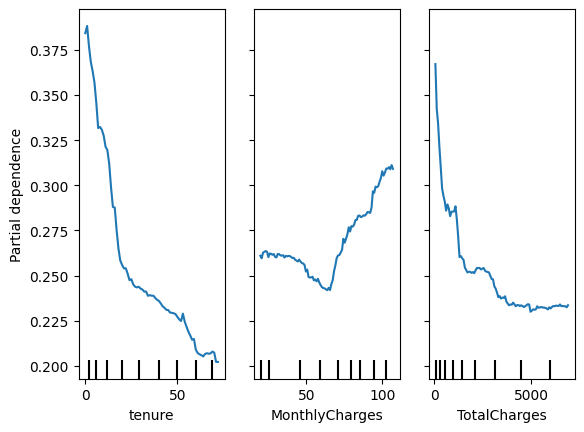

In [ ]:
# PARTIAL DEPENDENCE PLOTS (PDP)
print("\n Partial Dependence Plots : ")
top_features = [col for col in ['tenure', 'MonthlyCharges', 'TotalCharges'] if col in X_train.columns]

if top_features:
    PartialDependenceDisplay.from_estimator(model, X_train, top_features)
    plt.show()
else:
    print("Top features not found in dataset")

In [ ]:
# TOP 100 HIGH-RISK CUSTOMERS

print("\n Identifying Top 100 High-Risk Customers : ")
probs = model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results['actual_churn'] = y_test.values
results['churn_probability'] = probs
top_100 = results.sort_values(by='churn_probability', ascending=False).head(100)
print(top_100.head())


 Identifying Top 100 High-Risk Customers : 
      SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
1600              1        0           0       1             1   
4800              1        0           0       1             1   
2208              1        1           0       1             1   
1410              1        0           0       2             1   
2577              0        0           0       1             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  gender_Male  \
1600                 1           88.80         88.80         True   
4800                 1           94.00         94.00         True   
2208                 1          100.80        100.80        False   
1410                 1           93.85        170.85        False   
2577                 1           94.60         94.60        False   

      MultipleLines_No phone service  ...  StreamingTV_Yes  \
1600                           False  ...             True   
4800               

In [ ]:
# COST-BENEFIT ANALYSIS

print("\n Cost-Benefit Analysis : ")

cost = 50
loss = 500

# Model performance
model_saved = top_100['actual_churn'].sum()

# Random baseline
random_saved = int(y_test.mean() * 100)
model_profit = (model_saved * loss) - (100 * cost)
random_profit = (random_saved * loss) - (100 * cost)

print("FINAL BUSINESS ANALYSIS")
print("="*30)
print(f"Customers saved using model: {model_saved}")
print(f"Customers saved randomly:   {random_saved}")
print(f"Profit using model:         ${model_profit}")
print(f"Profit using random:        ${random_profit}")
print(f"Extra profit from model:    ${model_profit - random_profit}")



 Cost-Benefit Analysis : 
FINAL BUSINESS ANALYSIS
Customers saved using model: 84
Customers saved randomly:   26
Profit using model:         $37000
Profit using random:        $8000
Extra profit from model:    $29000


**SHAP Analysis (Global Feature Importance)**

Using SHAP values, we identified the most important features influencing customer churn. The top factors include tenure, monthly charges, contract type, internet service, and total charges. Among these, tenure has the strongest impact, where customers with lower tenure are more likely to churn. Similarly, customers with higher monthly charges show a higher probability of leaving the service. Contract type also plays a major role, as customers with month-to-month contracts tend to churn more compared to those with long-term contracts.

**Local Explanation (Individual Predictions)**

For individual predictions, SHAP helps explain why a specific customer is likely to churn or stay. For a churned customer, factors such as low tenure, high monthly charges, and flexible contract type increase churn probability. On the other hand, for a retained customer, longer tenure, lower charges, and stable contract plans contribute to customer retention. This helps in understanding customer behaviour at a detailed level.

**Partial Dependence Plot (PDP) Analysis**

The PDP analysis shows how features affect churn probability. Tenure has an inverse relationship with churn, meaning customers staying longer are less likely to leave. Monthly charges show a positive relationship, where higher charges increase churn risk. Contract type indicates that long-term contracts significantly reduce churn compared to short-term plans.


**Business**

**Top 5 Factors Driving Customer Churn**

The top factors driving churn are:

1.	Tenure (low tenure increases churn)

2.	Monthly Charges (higher charges increase churn)

3.	Contract Type (month-to-month customers churn more)

4.	Internet Service Type

5.	Total Charges


**High-Risk Customer Segments**

Customers at highest risk include:

1.	New customers (low tenure)

2.	Customers with high monthly charges

3.	Customers on month-to-month contracts

4.	Customers using basic or less stable services


 **Pricing Strategy Recommendation**

Based on the regression model, pricing plays a key role in customer retention. It is recommended to:

1.	Offer discounts or flexible pricing for high monthly charge customers

2.	Provide bundled services at lower cost

3.	Introduce loyalty rewards for long-term customers




**Target Customers for Intervention (Top 100)**

If the company can only target 100 customers, they should select those with the highest predicted churn probability from the model. These customers are most likely to leave, so intervening with them will give maximum benefit. The model helps in identifying these high-risk customers accurately instead of random selection.

**Cost-Benefit Analysis (ROI)**

Assuming it costs $50  

to retain a customer and losing a customer result in $500 loss:

- If we target 100 high-risk customers using the model:
  Cost = 100 × $50 = $5000  
  If even 30 customers are retained:
  Benefit = 30 × $500 = $15000  

  Net Profit = $15000 - $5000 = $10000  

- In random targeting:
  Fewer high-risk customers are selected, so retention is lower and profit is less.

